In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
path = r"C:\Users\SVS\Desktop\ML Project\data\ml_ready"
irrigation_sources = pd.read_csv( path + r"\Irrigation_Sources_ML.csv")

In [3]:
irrigation_sources.shape

(2832, 11)

In [4]:
irrigation_sources.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2832 entries, 0 to 2831
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       2832 non-null   int64  
 1   year                     2832 non-null   object 
 2   state_name               2832 non-null   object 
 3   state_code               2832 non-null   int64  
 4   district_name            2832 non-null   object 
 5   district_code            2832 non-null   float64
 6   irrigated_area_type      2832 non-null   object 
 7   area_classification      2832 non-null   object 
 8   area_sub_classification  2832 non-null   object 
 9   irrigated_area           2163 non-null   float64
 10  old_district_name        2832 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 243.5+ KB


In [5]:
irrigation_sources.head()

,id,year,state_name,state_code,district_name,district_code,irrigated_area_type,area_classification,area_sub_classification,irrigated_area,old_district_name
0,113712,2014-2015,Telangana,36,Adilabad,501.0,Gross Irrigated Area,Canal,Government,4987.0,Adilabad
1,113713,2014-2015,Telangana,36,Adilabad,501.0,Gross Irrigated Area,Canal,Private,NaN,Adilabad
2,113714,2014-2015,Telangana,36,Adilabad,501.0,Gross Irrigated Area,Other Source,Other Source,2615.0,Adilabad
3,113715,2014-2015,Telangana,36,Adilabad,501.0,Gross Irrigated Area,Tank,Tank,8673.0,Adilabad
4,113716,2014-2015,Telangana,36,Adilabad,501.0,Gross Irrigated Area,Well,Other Well,17632.0,Adilabad


In [6]:
irrigation_sources.dtypes

id                           int64
year                        object
state_name                  object
state_code                   int64
district_name               object
district_code              float64
irrigated_area_type         object
area_classification         object
area_sub_classification     object
irrigated_area             float64
old_district_name           object
dtype: object

In [7]:
irrigation_sources.columns

Index(['id', 'year', 'state_name', 'state_code', 'district_name',
       'district_code', 'irrigated_area_type', 'area_classification',
       'area_sub_classification', 'irrigated_area', 'old_district_name'],
      dtype='object')

In [8]:
irrigation_sources.duplicated().sum()

np.int64(0)

In [9]:
irrigation_sources.isnull().sum()

id                           0
year                         0
state_name                   0
state_code                   0
district_name                0
district_code                0
irrigated_area_type          0
area_classification          0
area_sub_classification      0
irrigated_area             669
old_district_name            0
dtype: int64

In [10]:
# 1. District + source + sub-source median
irrigation_sources["irrigated_area"] = (
    irrigation_sources["irrigated_area"].fillna(
        irrigation_sources.groupby(
            [
                "district_name",
                "area_classification",
                "area_sub_classification"
            ]
        )["irrigated_area"].transform("median")
    )
)

# 2. If still missing: District + source median
irrigation_sources["irrigated_area"] = (
    irrigation_sources["irrigated_area"].fillna(
        irrigation_sources.groupby(
            [
                "district_name",
                "area_classification"
            ]
        )["irrigated_area"].transform("median")
    )
)

# 3. Final fallback: overall median
irrigation_sources["irrigated_area"] = (
    irrigation_sources["irrigated_area"].fillna(
        irrigation_sources["irrigated_area"].median()
    )
)

In [11]:
irrigation_sources.isnull().sum()

id                         0
year                       0
state_name                 0
state_code                 0
district_name              0
district_code              0
irrigated_area_type        0
area_classification        0
area_sub_classification    0
irrigated_area             0
old_district_name          0
dtype: int64

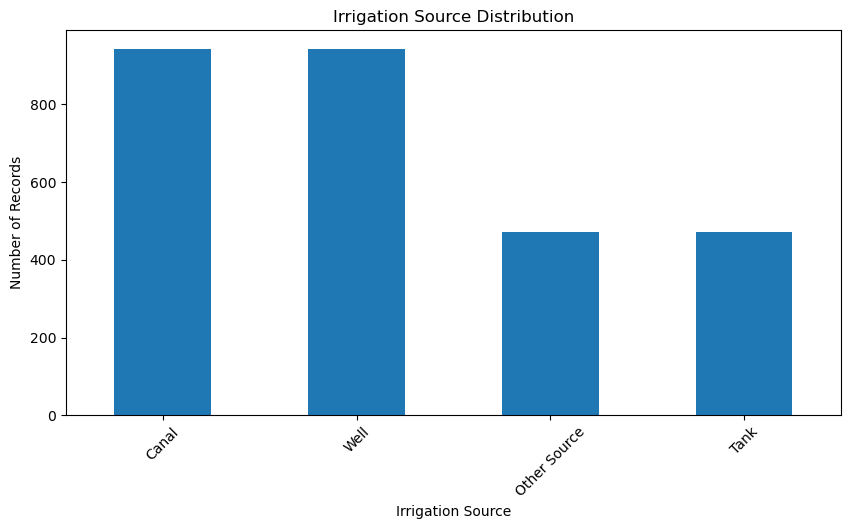

In [12]:
## Irrigation Source Distribution
plt.figure(figsize=(10, 5))

irrigation_sources["area_classification"].value_counts().plot(
    kind="bar"
)

plt.title("Irrigation Source Distribution")
plt.xlabel("Irrigation Source")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

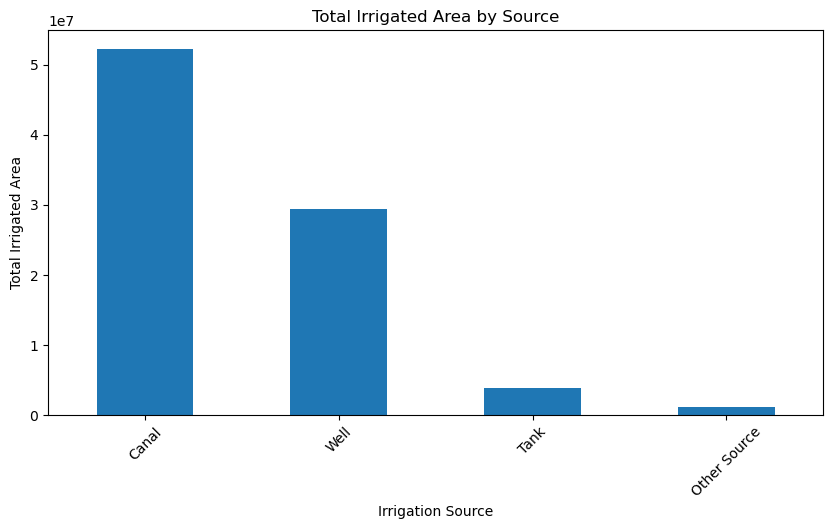

In [13]:
## Irrigated Area by Source
source_area = (
    irrigation_sources
    .groupby("area_classification")["irrigated_area"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

source_area.plot(kind="bar")

plt.title("Total Irrigated Area by Source")
plt.xlabel("Irrigation Source")
plt.ylabel("Total Irrigated Area")
plt.xticks(rotation=45)
plt.show()

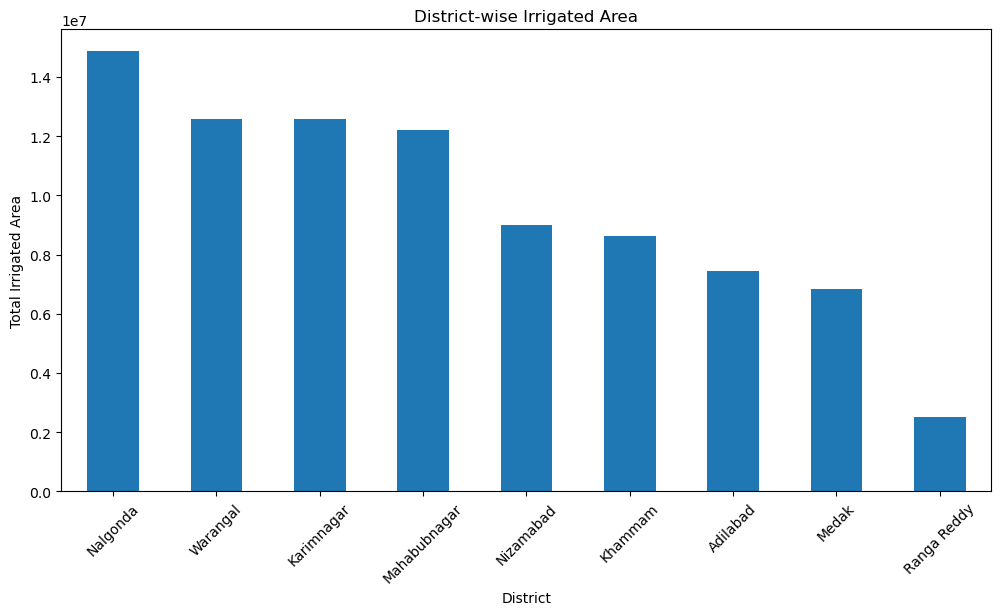

In [14]:
## District-wise Irrigated Area
district_area = (
    irrigation_sources
    .groupby("old_district_name")["irrigated_area"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

district_area.plot(kind="bar")

plt.title("District-wise Irrigated Area")
plt.xlabel("District")
plt.ylabel("Total Irrigated Area")
plt.xticks(rotation=45)
plt.show()

In [15]:
irrigation_sources["year_start"] = (
    irrigation_sources["year"]
    .astype(str)
    .str[:4]
    .astype(int)
)

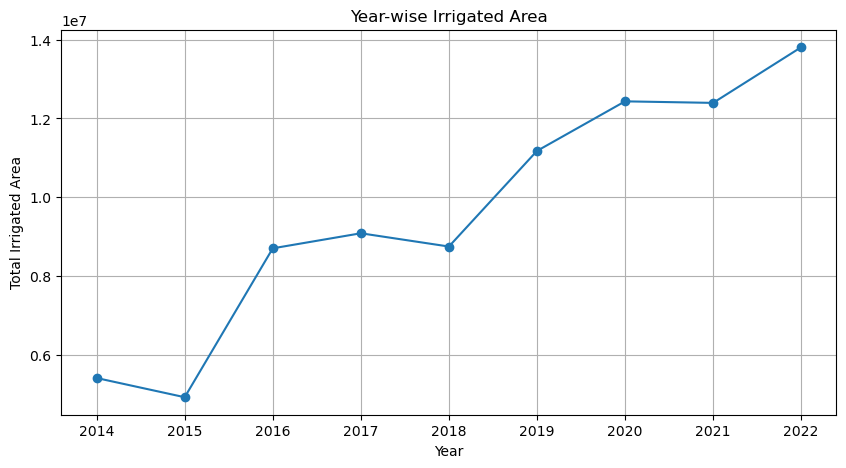

In [16]:
year_area = (
    irrigation_sources
    .groupby("year_start")["irrigated_area"]
    .sum()
)

plt.figure(figsize=(10, 5))

year_area.plot(
    kind="line",
    marker="o"
)

plt.title("Year-wise Irrigated Area")
plt.xlabel("Year")
plt.ylabel("Total Irrigated Area")
plt.grid()
plt.show()

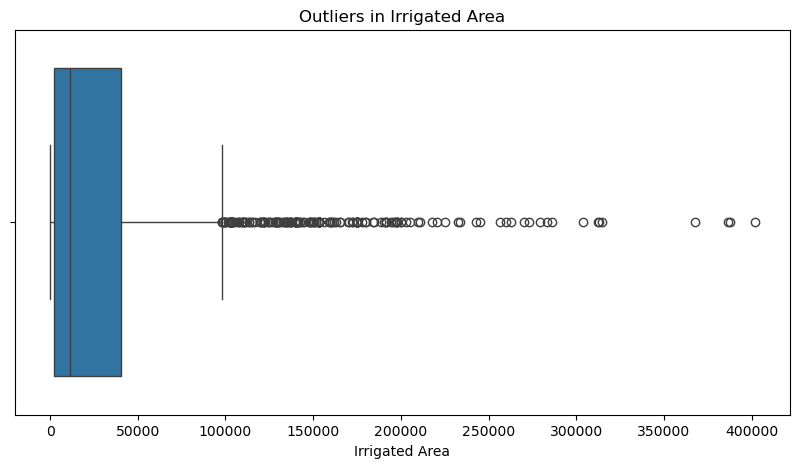

In [17]:
## Outliers
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=irrigation_sources["irrigated_area"].dropna()
)

plt.title("Outliers in Irrigated Area")
plt.xlabel("Irrigated Area")
plt.show()

In [18]:
Q1 = irrigation_sources["irrigated_area"].quantile(0.25)
Q3 = irrigation_sources["irrigated_area"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = irrigation_sources[
    (irrigation_sources["irrigated_area"] < lower) |
    (irrigation_sources["irrigated_area"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 216


## Feature Engineering 

In [19]:
## Previous-year irrigated area
irrigation_sources = irrigation_sources.sort_values(
    [
        "district_name",
        "area_classification",
        "area_sub_classification",
        "year_start"
    ]
)

irrigation_sources["previous_year_area"] = (
    irrigation_sources.groupby(
        [
            "district_name",
            "area_classification",
            "area_sub_classification"
        ]
    )["irrigated_area"].shift(1)
)

In [20]:
## Historical average
irrigation_sources["historical_avg_area"] = (
    irrigation_sources.groupby(
        [
            "district_name",
            "area_classification",
            "area_sub_classification"
        ]
    )["irrigated_area"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

In [21]:
## Year-to-year change
irrigation_sources["area_change"] = (
    irrigation_sources["irrigated_area"]
    - irrigation_sources["previous_year_area"]
)

In [22]:
## Percentage change
irrigation_sources["area_change_pct"] = np.where(
    irrigation_sources["previous_year_area"] > 0,
    (
        (
            irrigation_sources["irrigated_area"]
            - irrigation_sources["previous_year_area"]
        )
        / irrigation_sources["previous_year_area"]
    ) * 100,
    np.nan
)

In [23]:
irrigation_sources.head()

,id,year,state_name,state_code,district_name,district_code,irrigated_area_type,area_classification,area_sub_classification,irrigated_area,old_district_name,year_start,previous_year_area,historical_avg_area,area_change,area_change_pct
0,113712,2014-2015,Telangana,36,Adilabad,501.0,Gross Irrigated Area,Canal,Government,4987.0,Adilabad,2014,NaN,NaN,NaN,NaN
6,113718,2014-2015,Telangana,36,Adilabad,501.0,Net Irrigated Area,Canal,Government,4920.0,Adilabad,2014,4987.0,4987.000000,-67.0,-1.343493
108,120924,2015-2016,Telangana,36,Adilabad,501.0,Gross Irrigated Area,Canal,Government,4930.0,Adilabad,2015,4920.0,4953.500000,10.0,0.203252
114,120930,2015-2016,Telangana,36,Adilabad,501.0,Net Irrigated Area,Canal,Government,4773.0,Adilabad,2015,4930.0,4945.666667,-157.0,-3.184584
217,128136,2016-2017,Telangana,36,Adilabad,501.0,Gross Irrigated Area,Canal,Government,48726.0,Adilabad,2016,4773.0,4902.500000,43953.0,920.867379


## Univariate Analysis 

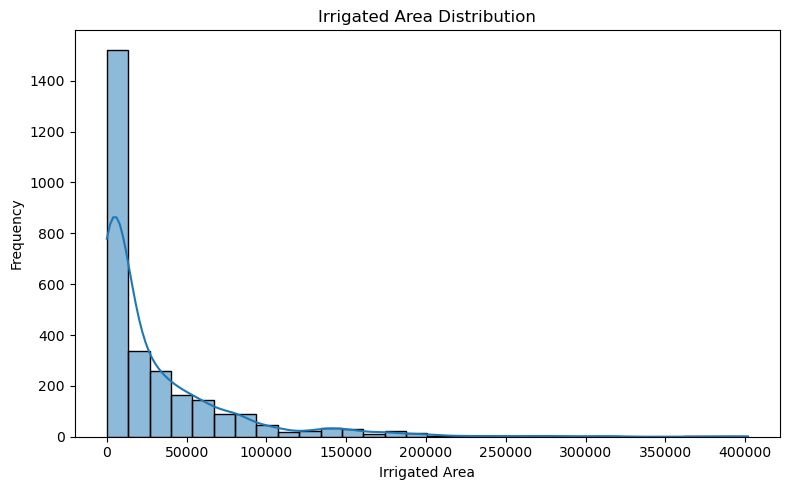

In [27]:
## Irrigated Area Distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    irrigation_sources["irrigated_area"].dropna(),
    bins=30,
    kde=True
)

plt.title("Irrigated Area Distribution")
plt.xlabel("Irrigated Area")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

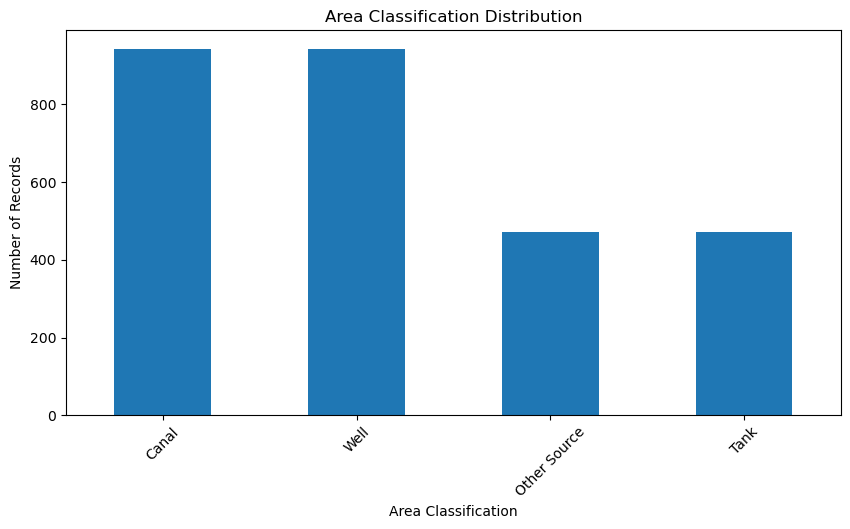

In [28]:
## Area Classification Distribution
plt.figure(figsize=(10, 5))

irrigation_sources["area_classification"].value_counts().plot(
    kind="bar"
)

plt.title("Area Classification Distribution")
plt.xlabel("Area Classification")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

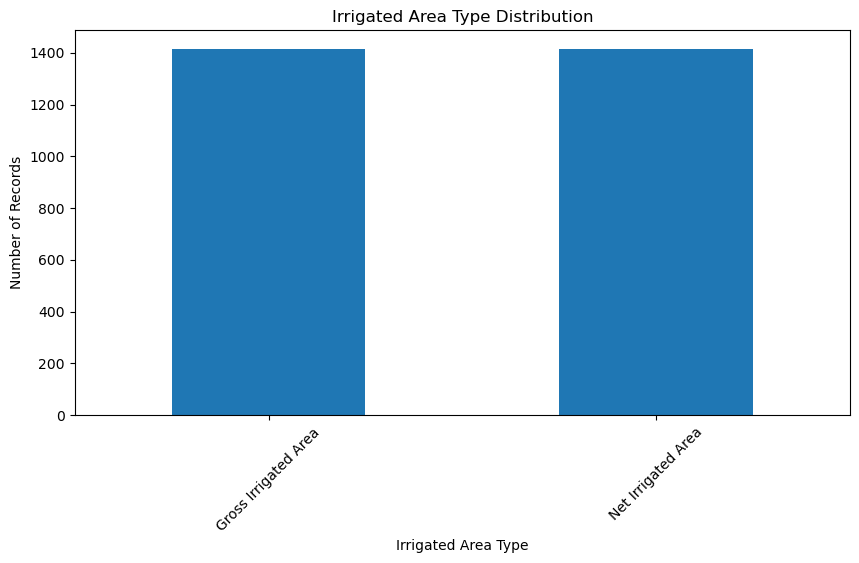

In [29]:
## Irrigated Area Type Distribution
plt.figure(figsize=(10, 5))

irrigation_sources["irrigated_area_type"].value_counts().plot(
    kind="bar"
)

plt.title("Irrigated Area Type Distribution")
plt.xlabel("Irrigated Area Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

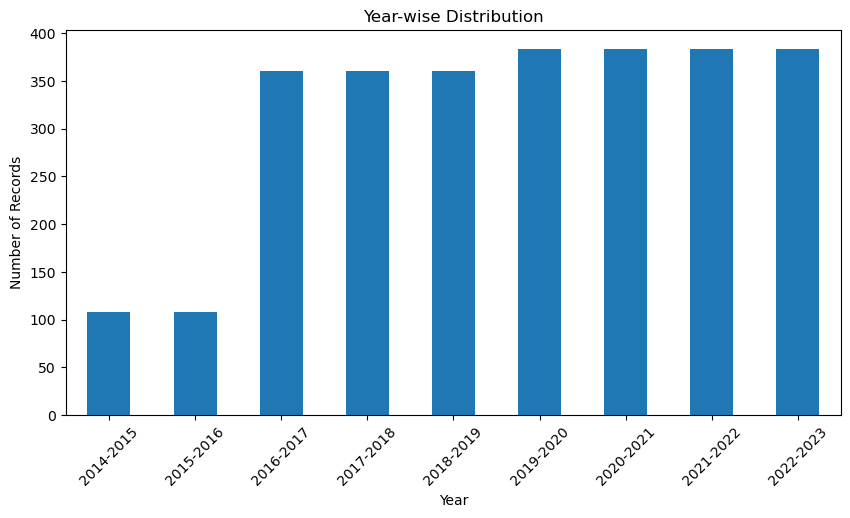

In [30]:
## Year Distribution
plt.figure(figsize=(10, 5))

irrigation_sources["year"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Year-wise Distribution")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

## Bivariate Analysis 

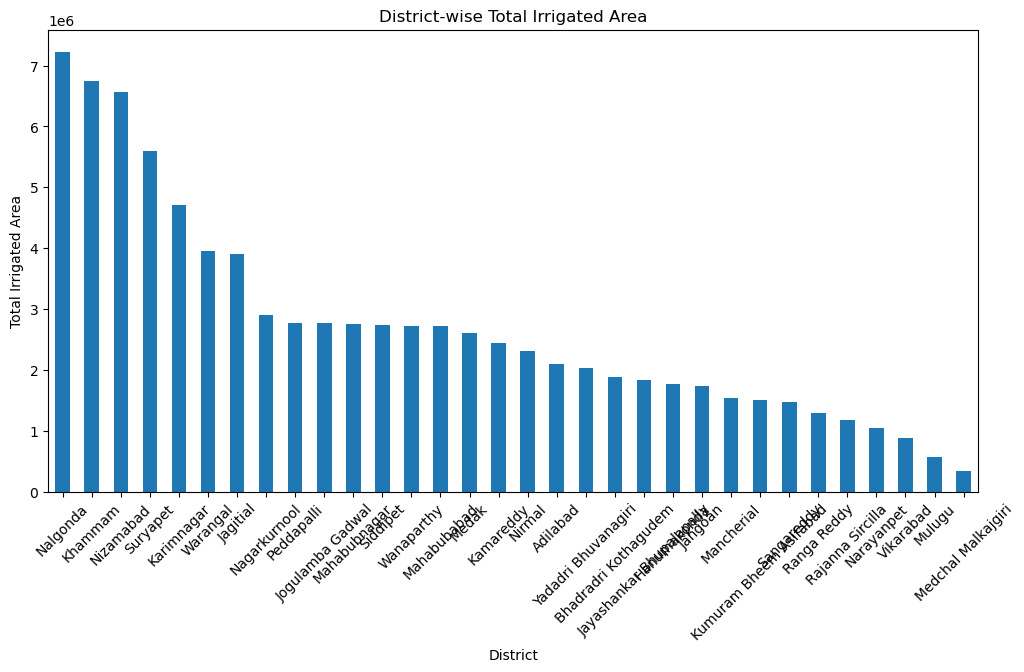

In [31]:
## District → Irrigated Area
district_area = (
    irrigation_sources.groupby("district_name")["irrigated_area"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

district_area.plot(kind="bar")

plt.title("District-wise Total Irrigated Area")
plt.xlabel("District")
plt.ylabel("Total Irrigated Area")
plt.xticks(rotation=45)
plt.show()

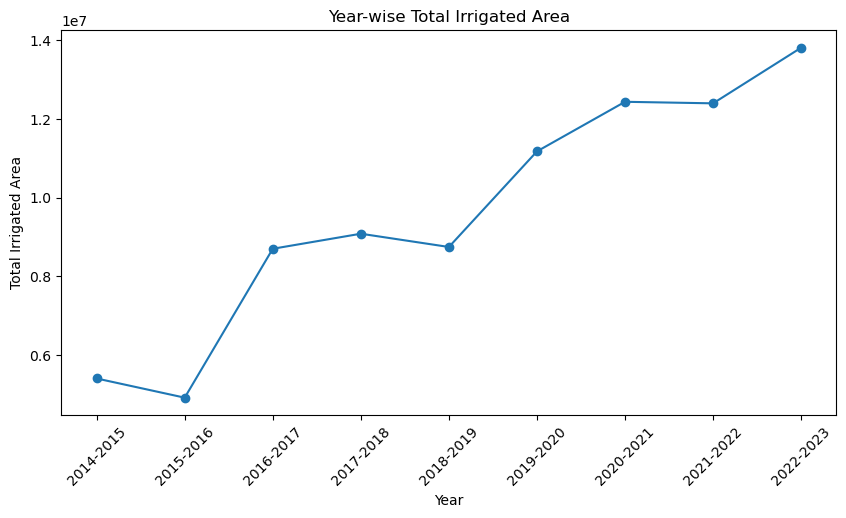

In [32]:
## Year → Irrigated Area
year_area = (
    irrigation_sources.groupby("year")["irrigated_area"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10, 5))

year_area.plot(
    kind="line",
    marker="o"
)

plt.title("Year-wise Total Irrigated Area")
plt.xlabel("Year")
plt.ylabel("Total Irrigated Area")
plt.xticks(rotation=45)
plt.show()

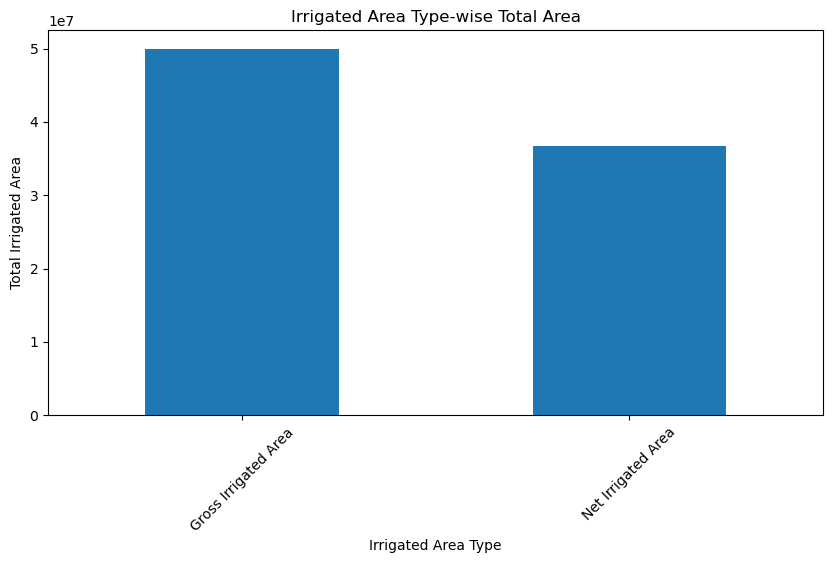

In [33]:
## Irrigated Area Type → Irrigated Area
type_area = (
    irrigation_sources.groupby("irrigated_area_type")["irrigated_area"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

type_area.plot(kind="bar")

plt.title("Irrigated Area Type-wise Total Area")
plt.xlabel("Irrigated Area Type")
plt.ylabel("Total Irrigated Area")
plt.xticks(rotation=45)
plt.show()

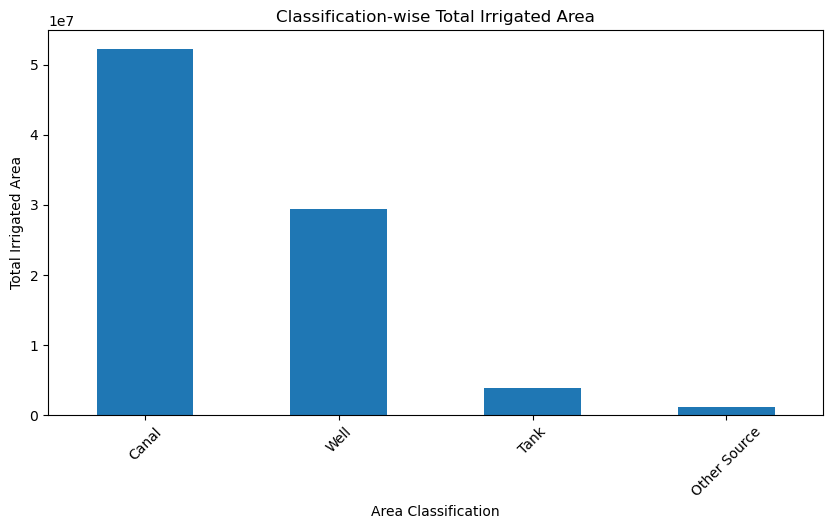

In [34]:
## Area Classification → Irrigated Area
classification_area = (
    irrigation_sources.groupby("area_classification")["irrigated_area"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

classification_area.plot(kind="bar")

plt.title("Classification-wise Total Irrigated Area")
plt.xlabel("Area Classification")
plt.ylabel("Total Irrigated Area")
plt.xticks(rotation=45)
plt.show()

## Multivariate Analyss 

In [35]:
## District + Year → Irrigated Area
district_year_area = (
    irrigation_sources.groupby(
        ["old_district_name", "year"]
    )["irrigated_area"]
    .sum()
    .reset_index()
)

print(district_year_area.head())

  old_district_name       year  irrigated_area
0          Adilabad  2014-2015        271774.0
1          Adilabad  2015-2016        282184.0
2          Adilabad  2016-2017        824372.0
3          Adilabad  2017-2018        901526.0
4          Adilabad  2018-2019        944546.0


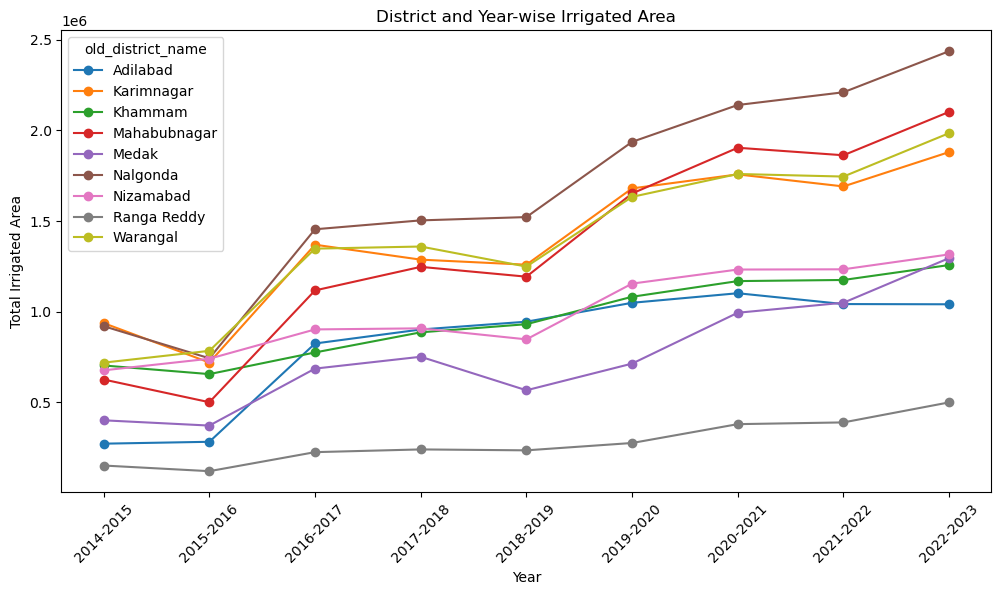

In [36]:
pivot = district_year_area.pivot(
    index="year",
    columns="old_district_name",
    values="irrigated_area"
)

pivot.plot(
    figsize=(12, 6),
    marker="o"
)

plt.title("District and Year-wise Irrigated Area")
plt.xlabel("Year")
plt.ylabel("Total Irrigated Area")
plt.xticks(rotation=45)
plt.show()

In [37]:
## District + Irrigated Area Type → Irrigated Area
district_type_area = (
    irrigation_sources.groupby(
        ["district_name", "irrigated_area_type"]
    )["irrigated_area"]
    .sum()
    .reset_index()
)

print(district_type_area.head())

          district_name   irrigated_area_type  irrigated_area
0              Adilabad  Gross Irrigated Area       1177257.0
1              Adilabad    Net Irrigated Area        916707.0
2  Bhadradri Kothagudem  Gross Irrigated Area       1021695.0
3  Bhadradri Kothagudem    Net Irrigated Area        867370.0
4           Hanumakonda  Gross Irrigated Area       1055780.0


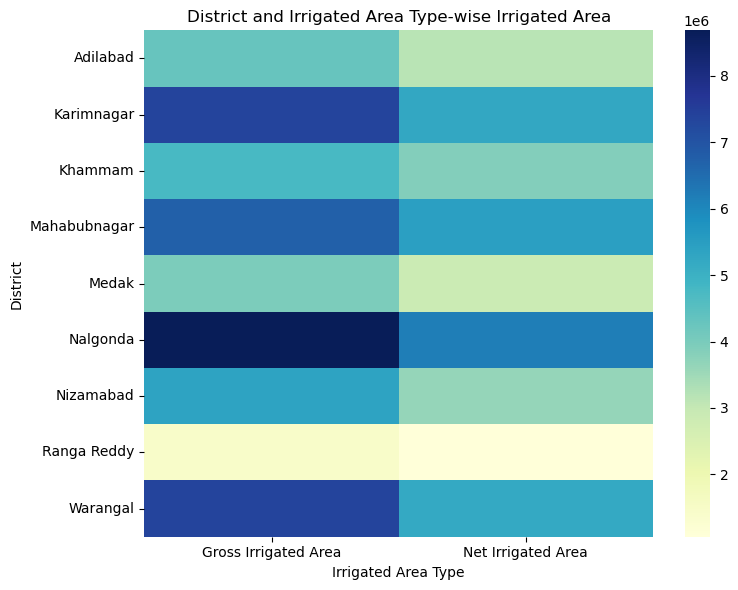

In [38]:
pivot = irrigation_sources.pivot_table(
    index="old_district_name",
    columns="irrigated_area_type",
    values="irrigated_area",
    aggfunc="sum"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    pivot,
    annot=False,
    cmap="YlGnBu"
)

plt.title("District and Irrigated Area Type-wise Irrigated Area")
plt.xlabel("Irrigated Area Type")
plt.ylabel("District")

plt.tight_layout()
plt.show()

In [39]:
## District + Year + Irrigated Area Type → Irrigated Area
district_year_type = (
    irrigation_sources.groupby(
        [
            "district_name",
            "year",
            "irrigated_area_type"
        ]
    )["irrigated_area"]
    .sum()
    .reset_index()
)

print(district_year_type.head())

  district_name       year   irrigated_area_type  irrigated_area
0      Adilabad  2014-2015  Gross Irrigated Area        150927.0
1      Adilabad  2014-2015    Net Irrigated Area        120847.0
2      Adilabad  2015-2016  Gross Irrigated Area        159410.0
3      Adilabad  2015-2016    Net Irrigated Area        122774.0
4      Adilabad  2016-2017  Gross Irrigated Area        107885.0


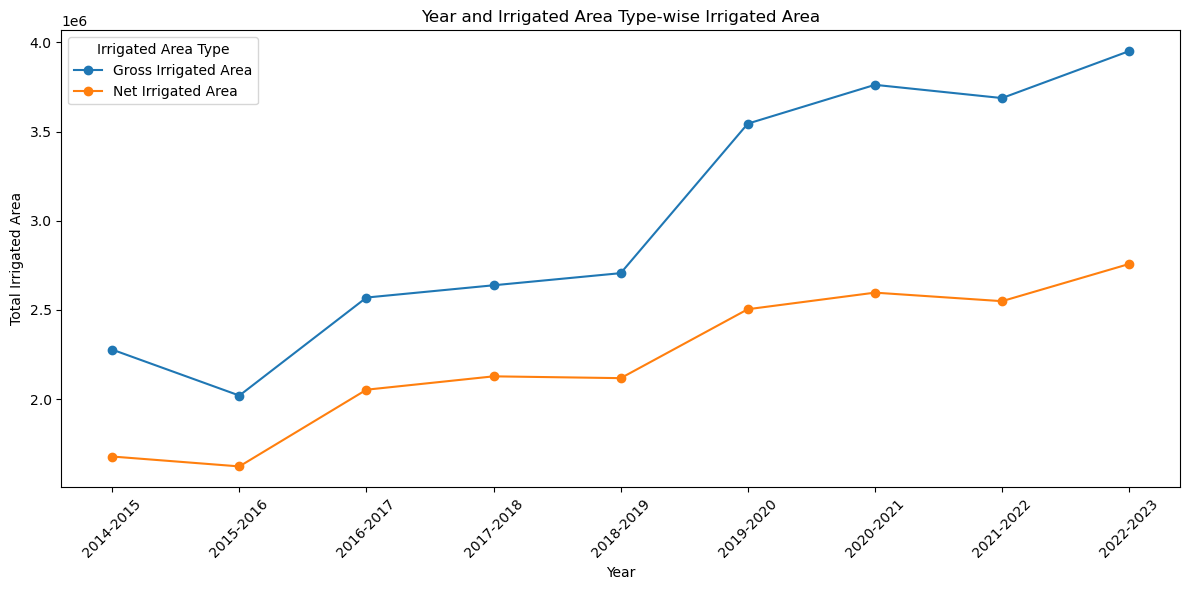

In [40]:
top_districts = (
    irrigation_sources.groupby("district_name")["irrigated_area"]
    .sum()
    .nlargest(10)
    .index
)

data = irrigation_sources[
    irrigation_sources["district_name"].isin(top_districts)
]

pivot = data.pivot_table(
    index="year",
    columns="irrigated_area_type",
    values="irrigated_area",
    aggfunc="sum"
)

plt.figure(figsize=(12, 6))

for col in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[col],
        marker="o",
        label=col
    )

plt.title("Year and Irrigated Area Type-wise Irrigated Area")
plt.xlabel("Year")
plt.ylabel("Total Irrigated Area")
plt.xticks(rotation=45)
plt.legend(title="Irrigated Area Type")

plt.tight_layout()
plt.show()

In [41]:
ml_path = r"C:\Users\SVS\Desktop\ML Project\data\ml_ready"

irrigation_sources.to_csv(
    ml_path + r"\Irrigation_source_Clean.csv",
    index=False
)

print("Irrigation_source_Clean.csv saved successfully.")

Irrigation_source_Clean.csv saved successfully.


## Insights 
- Irrigation Area Types
The dataset contains separate categories for Gross Irrigated Area and Net Irrigated Area.
These categories represent different measures of irrigation coverage and provide more detailed information than using a single total irrigated area.
- District, Year and Irrigated Area
  For Adilabad, irrigated area increased from approximately 271,774 in 2014–15 to 824,372 in 2016–17, reaching 944,546 in 2018–19.
This shows that irrigation availability changed substantially over time within the same district.
- Gross vs Net Irrigated Area
For Adilabad, Gross Irrigated Area is approximately 1,177,257, while Net Irrigated Area is approximately 916,707.
The difference of approximately 260,550 shows that gross and net irrigated area should not be considered the same measurement.